# CIFAR-10 Image Classification using CNN

**Name:** Gaurav Gour
**Reg No:** 23BSA10096

Application No:IN26011516


**Objective:** Build a Convolutional Neural Network (CNN) to classify images from the CIFAR-10 dataset into 10 categories with a target accuracy of 80%.

**Dataset:** CIFAR-10 — 50,000 training images, 10,000 test images, 32×32×3 (RGB)

In [1]:
# installing all the required libraries
!pip install tensorflow matplotlib numpy scipy scikit-learn seaborn

In [2]:
# importing the necessary libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# loading cifar-10 dataset (already split into train and test)
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# checking the shape of training and test data
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3413s 20us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


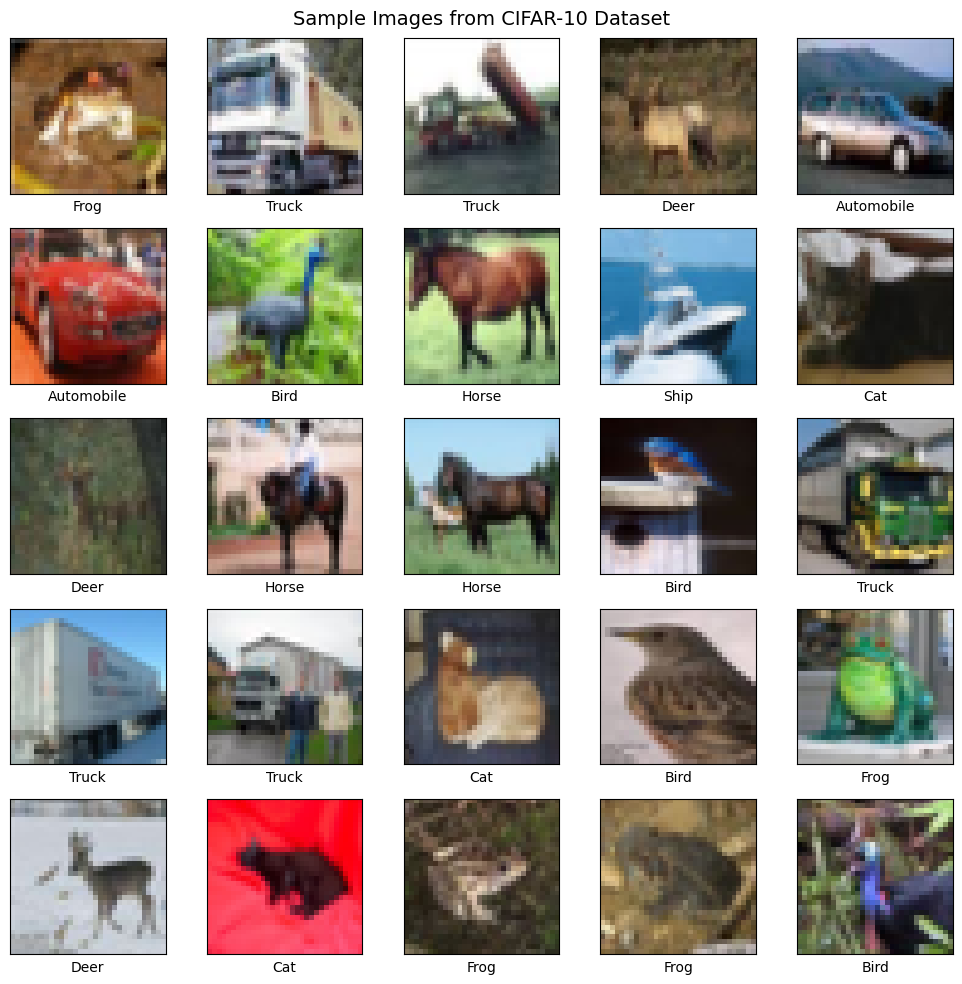

In [4]:
# cifar-10 has 10 categories
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# lets visualize some images from the dataset to understand it better
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.suptitle("Sample Images from CIFAR-10 Dataset", fontsize=14)
plt.tight_layout()
plt.show()


In [5]:
# normalizing pixel values to be between 0 and 1 (originally 0-255)
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Pixel value range after normalization:")
print("Min:", x_train.min(), "Max:", x_train.max())


Pixel value range after normalization:
Min: 0.0 Max: 1.0


In [6]:
# data augmentation - helps the model generalize better and avoid overfitting
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

In [7]:
# building the CNN model with batch normalization and dropout for regularization

model = models.Sequential()

# first conv block - 32 filters
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

# second conv block - 64 filters
model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

# third conv block - 128 filters
model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

# flattening and dense layers
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

# output layer - 10 classes with softmax
model.add(layers.Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
# compiling with adam optimizer
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# using learning rate reducer - reduces lr when accuracy plateaus
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# training with data augmentation for 30 epochs
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    epochs=30,
                    validation_data=(x_test, y_test),
                    callbacks=[lr_reducer])

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 286s 360ms/step - accuracy: 0.4101 - loss: 1.7207 - val_accuracy: 0.5373 - val_loss: 1.3248 - learning_rate: 0.0010
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 292s 374ms/step - accuracy: 0.5730 - loss: 1.1992 - val_accuracy: 0.6233 - val_loss: 1.0962 - learning_rate: 0.0010
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 293s 375ms/step - accuracy: 0.6393 - loss: 1.0234 - val_accuracy: 0.6529 - val_loss: 1.0144 - learning_rate: 0.0010
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 292s 374ms/step - accuracy: 0.6791 - loss: 0.9207 - val_accuracy: 0.6871 - val_loss: 0.9712 - learning_rate: 0.0010
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 286s 365ms/step - accuracy: 0.7050 - loss: 0.8499 - val_accuracy: 0.7491 - val_loss: 0.7312 - learning_rate: 0.0010
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 303s 388ms/step - accuracy: 0.7248 - loss: 0.7988 - val_accuracy: 0.7430 - val_loss: 0.7552 - learning_rate: 0.0010
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 291s 372ms/step - accura

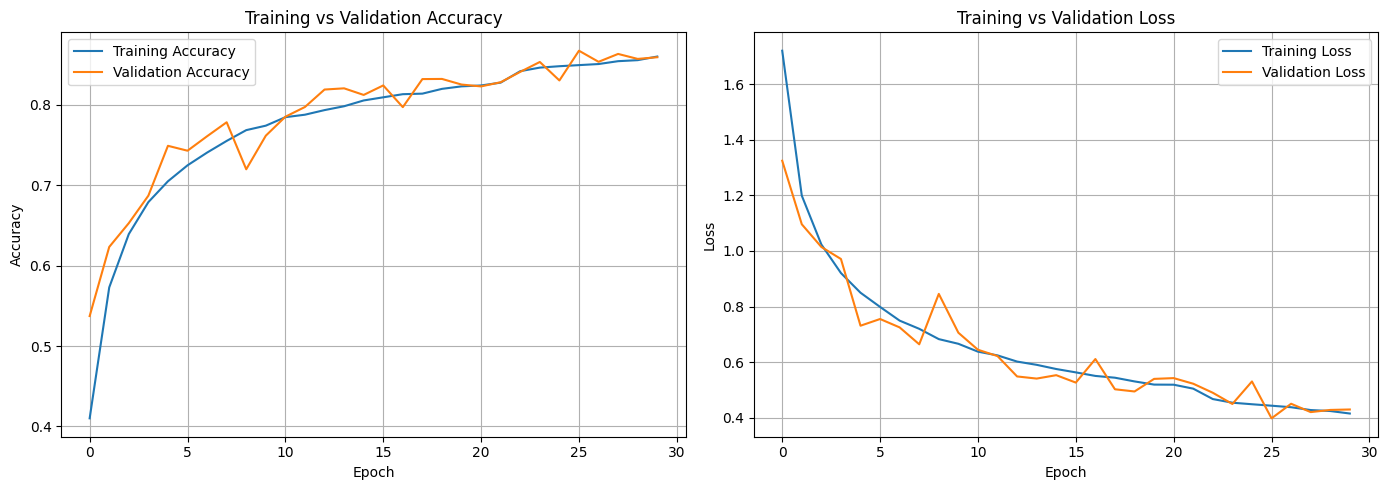


Final Training Accuracy: 86.02%
Final Validation Accuracy: 85.93%

✅ No significant overfitting - gap between train and val is only 0.09%


In [14]:
# plotting accuracy and loss curves to check for overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal Training Accuracy: {:.2f}%".format(history.history['accuracy'][-1] * 100))
print("Final Validation Accuracy: {:.2f}%".format(history.history['val_accuracy'][-1] * 100))

if history.history['val_accuracy'][-1] >= history.history['accuracy'][-1]:
    print("\n✅ No overfitting detected - validation accuracy is >= training accuracy")
else:
    gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    if gap < 0.05:
        print("\n✅ No significant overfitting - gap between train and val is only {:.2f}%".format(gap * 100))
    else:
        print("\n⚠️ Possible overfitting - gap is {:.2f}%".format(gap * 100))

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.8593 - loss: 0.4297

Test Accuracy: 85.93%
Test Loss: 0.4297
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


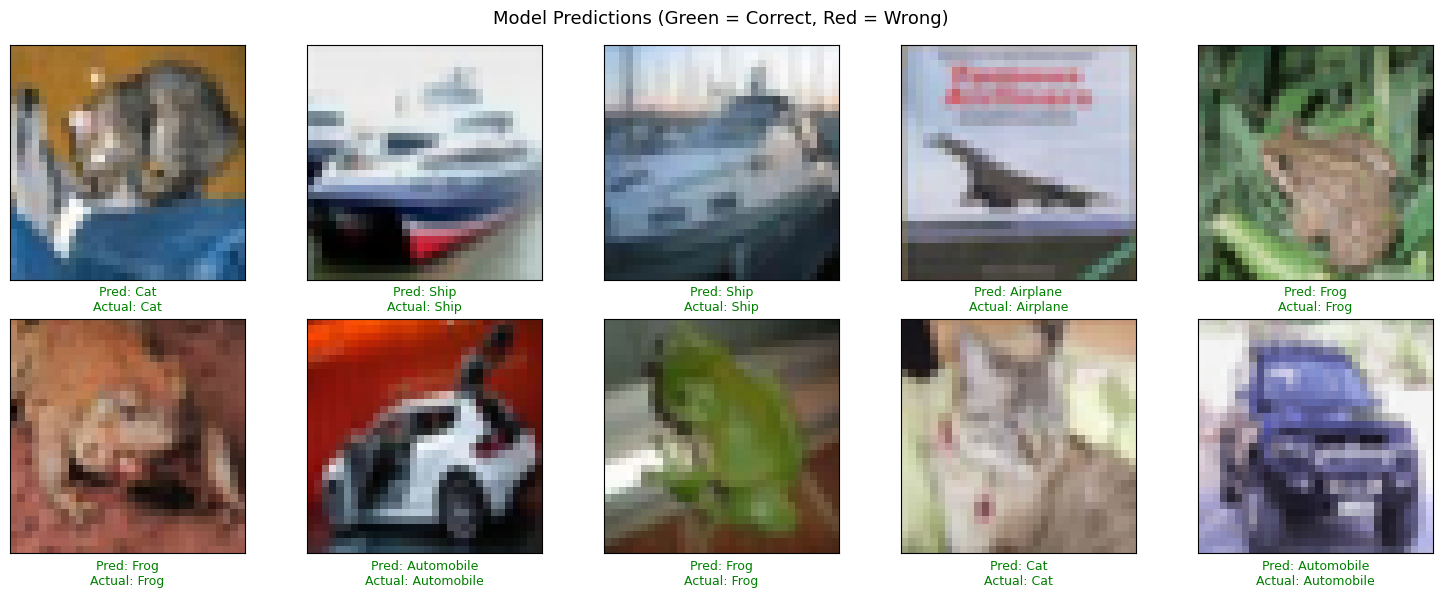

In [12]:
# evaluating model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print("\nTest Accuracy: {:.2f}%".format(test_accuracy * 100))
print("Test Loss: {:.4f}".format(test_loss))

# making predictions on some test images
predictions = model.predict(x_test[:10])

# visualizing predictions vs actual labels
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[i])
    predicted_label = class_names[np.argmax(predictions[i])]
    actual_label = class_names[y_test[i][0]]
    color = 'green' if predicted_label == actual_label else 'red'
    plt.xlabel(f"Pred: {predicted_label}\nActual: {actual_label}", color=color, fontsize=9)
plt.suptitle("Model Predictions (Green = Correct, Red = Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step
Classification Report:

              precision    recall  f1-score   support

    Airplane       0.91      0.86      0.88      1000
  Automobile       0.93      0.96      0.95      1000
        Bird       0.86      0.80      0.83      1000
         Cat       0.80      0.66      0.73      1000
        Deer       0.84      0.83      0.84      1000
         Dog       0.86      0.73      0.79      1000
        Frog       0.72      0.97      0.83      1000
       Horse       0.91      0.90      0.90      1000
        Ship       0.92      0.95      0.93      1000
       Truck       0.87      0.95      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



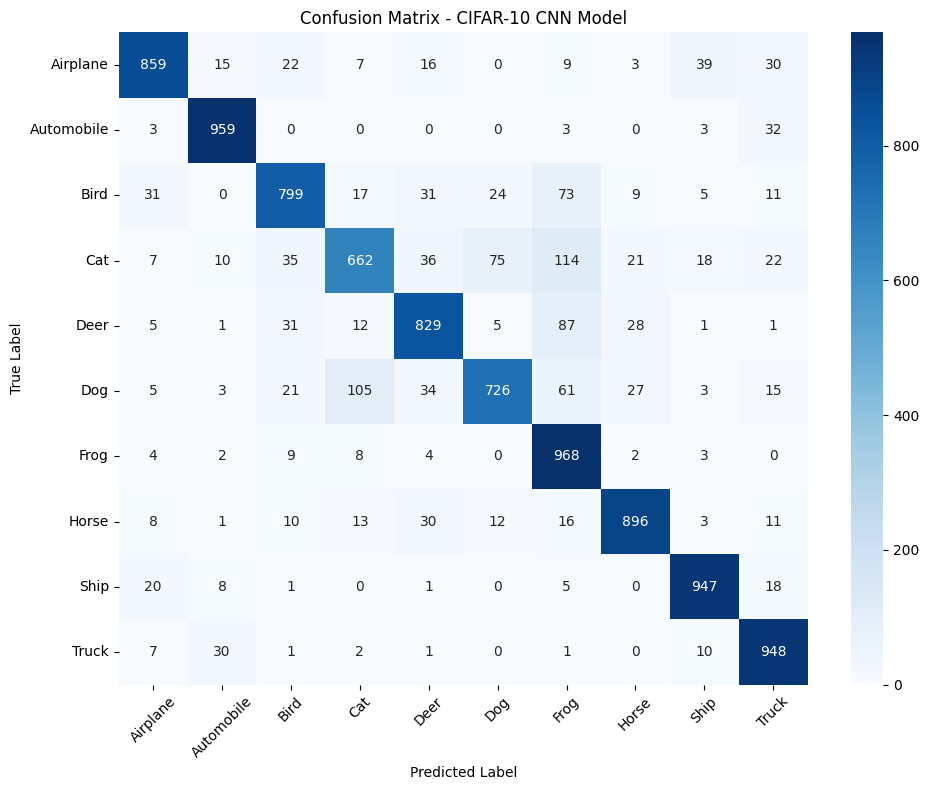


✅ Final Test Accuracy: 85.93% (Target was 85%)


In [13]:
# generating classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# getting predictions for all test images
y_pred = np.argmax(model.predict(x_test), axis=1)

# classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CIFAR-10 CNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Final Test Accuracy: {:.2f}% (Target was 85%)".format(test_accuracy * 100))